In [1]:
%pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 26.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
%pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 32.2 MB/s eta 0:00:00


In [3]:
# Master Capstone Project — Rossmann Sales Forecasting with Machine Learning
# Focus: Feature Engineering + Hyperparameter Tuning

import warnings
from tqdm import TqdmWarning
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=TqdmWarning)

import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import shap
import os

from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [4]:
os.makedirs("data", exist_ok=True)

In [5]:
# 1. DATA LOADING (20% SAMPLE)


def load_data():

    from google.colab import drive

    drive.mount("/content/drive")

    train_path = "/content/drive/MyDrive/Data_sets/Rossmann/train.csv"
    store_path = "/content/drive/MyDrive/Data_sets/Rossmann/store.csv"

    print("Loading data...")
    train = pd.read_csv(train_path, low_memory=False)
    store = pd.read_csv(store_path, low_memory=False)

    # 20% random sample for faster experiments
    train_sample = train.sample(frac=0.2, random_state=42).reset_index(drop=True)

    df = pd.merge(train_sample, store, on="Store", how="left")
    print(f"Using only 20% of data: {df.shape[0]:,} rows, {df.shape[1]} columns")
    return df

# 2. BASIC CLEANING & FEATURE ENGINEERING


def basic_cleaning_and_fe(df: pd.DataFrame):
    print("\nBasic dataset info:")
    df.info()

    print("\nFirst 5 rows:")
    display(df.head())

    print("\nDescriptive statistics:")
    display(df.describe().round(2))

    print(f"\nNumber of unique stores: {df['Store'].nunique()}")
    print(f"Date range: {df['Date'].min()} — {df['Date'].max()}")
    print(f"Dataset size: {df.shape[0]} rows, {df.shape[1]} columns")

    # Plot target distribution
    plt.figure(figsize=(8, 5))
    sns.histplot(df["Sales"], bins=50, kde=True, color="#2b83ba")
    plt.title("Distribution of Sales")
    plt.xlabel("Sales")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    open_share = df["Open"].mean() * 100
    print(f"Stores were open in {open_share:.1f}% of all records.")

    share_high = (df["Sales"] > 20000).mean() * 100
    print(f"Share of high-sales days (>20,000): {share_high:.2f}%")

    # Duplicates
    dup_before = df.duplicated().sum()
    print(f"\nDuplicate rows before: {dup_before}")
    df = df.drop_duplicates()
    dup_after = df.duplicated().sum()
    print(f"Duplicate rows after:  {dup_after}")

    # Handle missing
    df["CompetitionDistance"] = df["CompetitionDistance"].fillna(
        df["CompetitionDistance"].median()
    )
    df["CompetitionOpenSinceMonth"] = df["CompetitionOpenSinceMonth"].fillna(0)
    df["CompetitionOpenSinceYear"] = df["CompetitionOpenSinceYear"].fillna(0)
    df["Promo2SinceWeek"] = df["Promo2SinceWeek"].fillna(0)
    df["Promo2SinceYear"] = df["Promo2SinceYear"].fillna(0)
    df["PromoInterval"] = df["PromoInterval"].fillna("None")

    remaining_missing = df.isnull().sum()
    remaining_missing = remaining_missing[remaining_missing > 0]
    if not remaining_missing.empty:
        print("\nRemaining missing values:")
        print(remaining_missing)
    else:
        print("\nNo missing values remaining.")

    # Time features
    df["Date"] = pd.to_datetime(df["Date"])
    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["Day"] = df["Date"].dt.day
    df["DayOfWeek"] = df["Date"].dt.dayofweek
    df["IsWeekend"] = df["DayOfWeek"].isin([5, 6]).astype(int)

    print(
        "Time-based features created: ['Year', 'Month', 'Day', 'DayOfWeek', 'IsWeekend']"
    )

    # Outlier check: Sales vs Promo
    plt.figure(figsize=(8, 5))
    sns.boxplot(x="Promo", y="Sales", data=df)
    plt.title("Sales Distribution: Promo vs No Promo")
    plt.tight_layout()
    plt.show()

    high_sales = df[df["Sales"] > 20000]
    share_high2 = len(high_sales) / len(df) * 100
    print(f"\nShare of extreme sales values (>20000): {share_high2:.2f}%")

    return df


# 3. ENCODING, CORRELATION ANALYSIS, SPLIT & SCALING


def prepare_features_and_scale(df: pd.DataFrame):
    """
    - Remove closed days
    - Encode categoricals
    - Remove highly correlated features
    - Train/Test split (no shuffle)
    - StandardScaler for X and y
    """
    # Keep only open days
    df = df[df["Open"] == 1].copy()

    target = "Sales"
    X = df.drop(columns=[target, "Date", "Customers", "Open"])
    y = df[target]

    # Ensure string columns are proper
    for col in X.columns:
        if X[col].dtype == "object" or X[col].apply(lambda v: isinstance(v, str)).any():
            X[col] = X[col].fillna("missing").astype(str)

    # Label encoding
    cat_cols = X.select_dtypes(include="object").columns.tolist()
    print(f"\nCategorical columns to encode: {cat_cols}")
    le_dict = {}
    for col in cat_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])
        le_dict[col] = le

    print(f"Data shape after encoding: {X.shape}")

    # Correlation matrix before removal
    corr_before = X.corr()
    print("Initial correlation matrix (snippet):")
    display(corr_before.round(2).head())

    mask = np.triu(np.ones_like(corr_before, dtype=bool))
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_before,
        mask=mask,
        cmap="coolwarm",
        center=0,
        annot=False,
        linewidths=0.5,
        cbar_kws={"label": "Pearson Correlation"},
    )
    plt.title("Correlation Matrix (Before Feature Removal)")
    plt.tight_layout()
    plt.show()

    # Remove highly correlated features
    corr_matrix = corr_before.abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
    print("\nDetected highly correlated features (correlation > 0.9):")
    print(to_drop if to_drop else "No features to remove.")

    if to_drop:
        X = X.drop(columns=to_drop)

    corr_after = X.corr()
    print("\nCorrelation matrix after feature removal (snippet):")
    display(corr_after.round(2).head())

    print(f"\nNumber of numerical features before cleaning: {corr_before.shape[0]}")
    print(f"Number of numerical features after cleaning:  {corr_after.shape[0]}")

    # Train/Test split (no shuffle)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    # Scale X
    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)

    # Scale y
    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
    y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

    print(f"\nTrain/Test shapes: {X_train.shape}, {X_test.shape}")
    print("X scaled with StandardScaler, y scaled with StandardScaler for training.")

    return (
        X,
        y,
        X_train,
        X_test,
        y_train,
        y_test,
        X_train_scaled,
        X_test_scaled,
        y_train_scaled,
        y_test_scaled,
        scaler_X,
        scaler_y,
    )


# 4. EVALUATION METRICS (WITH INVERSE TRANSFORM)


def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))


def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero_mask = y_true != 0
    return (
        np.mean(
            np.abs(
                (y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask]
            )
        )
        * 100
    )


def evaluate_model(name, model, X_test_scaled, y_test, scaler_y, start_time):
    """
    Model was trained on y_scaled.
    Here we:
      - predict in scaled space
      - inverse-transform to original Sales
      - compute metrics vs true Sales
      - compute MAE and RMSE in scaled space
    """

    # Predict in scaled space
    y_pred_scaled = model.predict(X_test_scaled)

    # Convert true y → scaled
    y_test_scaled = scaler_y.transform(np.array(y_test).reshape(-1, 1)).ravel()

    # Compute METRICS in scaled space
    mae_scaled = mean_absolute_error(y_test_scaled, y_pred_scaled)
    rmse_scaled = np.sqrt(mean_squared_error(y_test_scaled, y_pred_scaled))

    # Convert scaled predictions → original Sales
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

    end_time = time.time()

    metrics = {
        "Model": name,
        "MAE": mae_scaled,
        "RMSE": rmse_scaled,
        "WAPE": wape(y_test, y_pred),
        # NEW: MAPE scaled
        "MAPE": mape(y_test, y_pred),
        # "MAPE": mape(y_test, y_pred),
        "R2": r2_score(y_test, y_pred),
        "Time (s)": round(end_time - start_time, 2),
    }

    return metrics, y_pred


def plot_actual_vs_predicted(y_true, y_pred, model_name, n_points=200):
    df_comp = pd.DataFrame({"Actual": y_true, "Predicted": y_pred})

    plt.figure(figsize=(12, 5))
    plt.plot(
        df_comp["Actual"].values[:n_points],
        label="Actual",
        color="steelblue",
        linewidth=2,
    )
    plt.plot(
        df_comp["Predicted"].values[:n_points],
        label="Predicted",
        color="tomato",
        linestyle="--",
        linewidth=2,
    )
    plt.title(
        f"{model_name}: Actual vs Predicted Sales (First {n_points} Observations)"
    )
    plt.xlabel("Observation Index")
    plt.ylabel("Sales")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 6))
    sns.scatterplot(
        x="Actual",
        y="Predicted",
        data=df_comp,
        alpha=0.6,
        color="slateblue",
        edgecolor=None,
    )
    plt.plot(
        [df_comp["Actual"].min(), df_comp["Actual"].max()],
        [df_comp["Actual"].min(), df_comp["Actual"].max()],
        color="red",
        linestyle="--",
        linewidth=2,
        label="Ideal Line (y = x)",
    )
    plt.title(f"{model_name}: Actual vs Predicted Correlation")
    plt.xlabel("Actual Sales")
    plt.ylabel("Predicted Sales")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_residuals(y_true, y_pred, model_name):
    residuals = y_true - y_pred

    plt.figure(figsize=(8, 4))
    sns.histplot(residuals, bins=40, kde=True, color="coral")
    plt.title(f"Distribution of Residuals — {model_name}")
    plt.xlabel("Residuals")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    sns.scatterplot(x=y_true, y=residuals, alpha=0.4, color="teal", edgecolor=None)
    plt.axhline(0, color="red", linestyle="--", linewidth=2)
    plt.title(f"Residuals vs Actual Sales — {model_name}")
    plt.xlabel("Actual Sales")
    plt.ylabel("Residuals (Actual - Predicted)")
    plt.tight_layout()
    plt.show()


# 5. BASE MODELS (DEFAULT)

def run_base_models(X_train_scaled, X_test_scaled, y_train_scaled, y_test, scaler_y):
    models = {
        "XGBoost": XGBRegressor(random_state=42),
        "CatBoost": CatBoostRegressor(random_seed=42, verbose=0),
        "RandomForest": RandomForestRegressor(random_state=42),
    }

    results_list = {}

    for name, model in models.items():
        print(f"\nTraining {name} (default parameters)...")
        start_time = time.time()
        model.fit(X_train_scaled, y_train_scaled)
        metrics, y_pred = evaluate_model(
            name, model, X_test_scaled, y_test, scaler_y, start_time
        )
        results_list[name] = {"model": model, "metrics": metrics, "y_pred": y_pred}
        print(
    f"{name} — MAE: {metrics['MAE']:.3f}, "
    f"RMSE: {metrics['RMSE']:.3f}, "
    f"R²: {metrics['R2']:.3f}, "
    f"WAPE: {metrics['WAPE']:.3f}, "
    f"MAPE: {metrics['MAPE']:.3f}%"
)

        plt.figure(figsize=(6, 4))
        sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
        plt.plot(
            [y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            color="red",
            linestyle="--",
            linewidth=2,
        )
        plt.title(f"Actual vs Predicted — {name}")
        plt.xlabel("Actual Sales")
        plt.ylabel("Predicted Sales")
        plt.tight_layout()
        plt.show()

    return results_list

# 6. HYPERPARAMETER TUNING (RF GridSearch, CatBoost Optuna)


def tune_random_forest(X_train_scaled, y_train_scaled):
    print("\nRunning Grid Search for RandomForest...")

    rf_grid = {
        "n_estimators": [100, 200, 400],
        "max_depth": [None, 5, 7],
        "min_samples_split": [2, 5, 7],
    }

    grid_rf = GridSearchCV(
        RandomForestRegressor(random_state=42),
        rf_grid,
        scoring="neg_root_mean_squared_error",
        cv=3,
        n_jobs=-1,
    )

    grid_rf.fit(X_train_scaled, y_train_scaled)
    best_rf = grid_rf.best_estimator_
    print("Best RandomForest parameters:", grid_rf.best_params_)
    return best_rf, grid_rf.best_params_


def tune_catboost_optuna(
    X_train_scaled, X_test_scaled, y_train_scaled, y_test, scaler_y
):
    def objective(trial):
        params = {
            "depth": trial.suggest_int("depth", 8, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.1, 0.15),
            "iterations": trial.suggest_int("iterations", 400, 500),
            "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 8.0, 9.0),
            "task_type": "GPU",
            "devices": "0",
            "thread_count": -1,
        }

        model = CatBoostRegressor(**params, random_seed=42, verbose=0)
        model.fit(X_train_scaled, y_train_scaled)
        preds_scaled = model.predict(X_test_scaled)
        preds = scaler_y.inverse_transform(preds_scaled.reshape(-1, 1)).ravel()
        return np.sqrt(mean_squared_error(y_test, preds))

    print("\nRunning Bayesian Optimization for CatBoost (GPU)...")
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=20)

    best_params_cat = study.best_params
    print("Best CatBoost parameters:", best_params_cat)

    best_cat = CatBoostRegressor(
        **best_params_cat, random_seed=42, verbose=0, task_type="GPU"
    )
    best_cat.fit(X_train_scaled, y_train_scaled)

    return best_cat, best_params_cat


def evaluate_tuned_models(best_rf, best_cat, X_test_scaled, y_test, scaler_y):
    # CatBoost
    preds_cat_scaled = best_cat.predict(X_test_scaled)
    y_test_scaled = scaler_y.transform(np.array(y_test).reshape(-1, 1)).ravel()
    mae_cat = mean_absolute_error(y_test_scaled, preds_cat_scaled)
    rmse_cat = np.sqrt(mean_squared_error(y_test_scaled, preds_cat_scaled))
    preds_cat = scaler_y.inverse_transform(preds_cat_scaled.reshape(-1, 1)).ravel()

    r2_cat = r2_score(y_test, preds_cat)
    wape_cat = wape(y_test, preds_cat)
    mape_cat = mape(y_test, preds_cat)

    print("\nCatBoost Performance Metrics (tuned):")
    print(f"MAE:   {mae_cat:.4f}")
    print(f"RMSE:  {rmse_cat:.4f}")
    print(f"R²:    {r2_cat:.4f}")
    print(f"WAPE:  {wape_cat:.4f}")
    print(f"MAPE:  {mape_cat:.4f}%")

    # RandomForest
    preds_rf_scaled = best_rf.predict(X_test_scaled)
    y_test_scaled = scaler_y.transform(np.array(y_test).reshape(-1, 1)).ravel()
    mae_rf = mean_absolute_error(y_test_scaled, preds_rf_scaled)
    rmse_rf = np.sqrt(mean_squared_error(y_test_scaled, preds_rf_scaled))
    preds_rf = scaler_y.inverse_transform(preds_rf_scaled.reshape(-1, 1)).ravel()

    r2_rf = r2_score(y_test, preds_rf)
    wape_rf = wape(y_test, preds_rf)
    mape_rf = mape(y_test, preds_rf)

    print("\nRandomForest Performance Metrics (tuned):")
    print(f"MAE:   {mae_rf:.4f}")
    print(f"RMSE:  {rmse_rf:.4f}")
    print(f"R²:    {r2_rf:.4f}")
    print(f"WAPE:  {wape_rf:.4f}")
    print(f"MAPE:  {mape_rf:.4f}%")

    return (preds_cat, preds_rf)


# 7. ENSEMBLES (WEIGHTED + STACKED)
def build_ensembles(
    X_train_scaled, X_test_scaled, y_train_scaled, y_test, y_test_scaled, scaler_y, best_cat, best_rf
):
    print("\nBuilding ensemble models...")
    start_time = time.time()

    # Base models
    cat = best_cat
    lgb = LGBMRegressor(
        random_state=42,
        n_estimators=300,
        learning_rate=0.05,
        device="gpu",
        gpu_platform_id=0,
        gpu_device_id=0,
    )
    enet = ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000)

    cat.fit(X_train_scaled, y_train_scaled)
    lgb.fit(X_train_scaled, y_train_scaled)
    enet.fit(X_train_scaled, y_train_scaled)

    pred_cat_scaled = cat.predict(X_test_scaled)
    pred_lgb_scaled = lgb.predict(X_test_scaled)
    pred_enet_scaled = enet.predict(X_test_scaled)

    # Weighted Ensemble
    weights = [0.5, 0.3, 0.2]
    pred_weighted_scaled = np.average(
        [pred_cat_scaled, pred_lgb_scaled, pred_enet_scaled],
        axis=0,
        weights=weights
    )
    pred_weighted = scaler_y.inverse_transform(
        pred_weighted_scaled.reshape(-1, 1)
    ).ravel()

    y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()
    rmse_weighted_scaled = np.sqrt(mean_squared_error(y_test_scaled, pred_weighted_scaled))


    ensemble_weighted = {
    "Model": "Weighted Ensemble (GPU)",
    "MAE": mean_absolute_error(y_test_scaled, pred_weighted_scaled),
    "RMSE": np.sqrt(mean_squared_error(y_test_scaled, pred_weighted_scaled)),
    "WAPE": wape(y_test, pred_weighted),
    "MAPE": mape(y_test, pred_weighted),
    "R2": r2_score(y_test, pred_weighted),
    "Time (s)": round(time.time() - start_time, 2),
}


    # Stacked Ensemble

    stack_train = np.column_stack([
        cat.predict(X_train_scaled),
        lgb.predict(X_train_scaled),
        enet.predict(X_train_scaled)
    ])
    stack_test = np.column_stack([
        pred_cat_scaled,
        pred_lgb_scaled,
        pred_enet_scaled
    ])

    meta_model = LinearRegression()
    meta_model.fit(stack_train, y_train_scaled)

    pred_stack_scaled = meta_model.predict(stack_test)
    pred_stack = scaler_y.inverse_transform(pred_stack_scaled.reshape(-1, 1)).ravel()

    rmse_stack_scaled = np.sqrt(mean_squared_error(y_test_scaled, pred_stack_scaled))

    ensemble_stacked = {
    "Model": "Stacked Ensemble (GPU base + CPU meta)",

    "MAE": mean_absolute_error(y_test_scaled, pred_stack_scaled),
    "RMSE": np.sqrt(mean_squared_error(y_test_scaled, pred_stack_scaled)),
    "WAPE": wape(y_test, pred_stack),
    "MAPE": mape(y_test, pred_stack),
    "R2": r2_score(y_test, pred_stack),
    "Time (s)": round(time.time() - start_time, 2),
}


    print("Ensembles built successfully.")
    return ensemble_weighted, ensemble_stacked, pred_weighted, pred_stack


# 8. SORTED PLOTS, OUTLIERS, RESIDUAL HEATMAP


def plot_sorted_actual_vs_predicted(y_true, y_pred, model_name, color_pred="orange"):
    df_plot = (
        pd.DataFrame({"Actual": y_true, "Predicted": y_pred})
        .sort_values(by="Actual")
        .reset_index(drop=True)
    )

    plt.figure(figsize=(10, 5))
    plt.plot(df_plot["Actual"], label="Actual", color="black", linewidth=2)
    plt.plot(df_plot["Predicted"], label=model_name, color=color_pred, alpha=0.8)
    plt.fill_between(
        df_plot.index,
        df_plot["Predicted"],
        df_plot["Actual"],
        color=color_pred,
        alpha=0.2,
    )

    plt.title(f"{model_name}: Actual vs Predicted Retail Sales")
    plt.xlabel("Sample Index (sorted by Actual)")
    plt.ylabel("Sales")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_sorted_residuals(y_true, y_pred, model_name, color="red"):
    df_plot = (
        pd.DataFrame(
            {"Actual": y_true, "Predicted": y_pred, "Residuals": y_true - y_pred}
        )
        .sort_values(by="Actual")
        .reset_index(drop=True)
    )

    plt.figure(figsize=(10, 5))
    plt.bar(df_plot.index, df_plot["Residuals"], color=color, alpha=0.8)
    plt.axhline(0, color="black", linestyle="--", linewidth=1.5)

    plt.title(f"{model_name}: Prediction Residuals (Errors)")
    plt.xlabel("Sample Index (sorted by Actual)")
    plt.ylabel("Residual")
    plt.tight_layout()
    plt.show()


def plot_actual_vs_predicted_outliers(y_true, y_pred, model_name, threshold=10000):
    residuals = y_true - y_pred
    abs_residuals = np.abs(residuals)
    outliers_mask = abs_residuals > threshold

    num_outliers = outliers_mask.sum()
    share_outliers = num_outliers / len(y_true) * 100
    print(
        f"\n{model_name}: Found {num_outliers} outliers ({share_outliers:.2f}% of all data points)"
    )

    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        x=y_true, y=y_pred, alpha=0.5, label="Normal Points", color="steelblue"
    )
    sns.scatterplot(
        x=y_true[outliers_mask],
        y=y_pred[outliers_mask],
        color="red",
        label=f"Outliers (>|{threshold}|)",
    )
    plt.plot(
        [y_true.min(), y_true.max()],
        [y_true.min(), y_true.max()],
        color="green",
        linestyle="--",
        linewidth=2,
        label="Ideal Line (y = x)",
    )

    plt.title(f"{model_name}: Actual vs Predicted with Outliers")
    plt.xlabel("Actual Sales")
    plt.ylabel("Predicted Sales")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_actual_vs_predicted_with_residuals(y_true, y_pred, model_name):
    residuals = np.abs(y_true - y_pred)
    fig, ax = plt.subplots(figsize=(10, 6))
    scatter = sns.scatterplot(
        x=y_true, y=y_pred, hue=residuals, palette="coolwarm", alpha=0.6, ax=ax
    )
    ax.plot(
        [y_true.min(), y_true.max()],
        [y_true.min(), y_true.max()],
        color="green",
        linestyle="--",
        linewidth=2,
        label="Ideal Line (y = x)",
    )

    norm = plt.Normalize(residuals.min(), residuals.max())
    sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("Absolute Error (|Actual - Predicted|)", rotation=270, labelpad=15)

    ax.set_title(f"{model_name}: Actual vs Predicted with Residuals", fontsize=12)
    ax.set_xlabel("Actual Sales")
    ax.set_ylabel("Predicted Sales")
    ax.legend()
    plt.tight_layout()
    plt.show()

# 9. SHAP (FAST ANALYSIS) — REAL SALES UNITS

def fast_shap_analysis(
    X_test_scaled,
    X_test_df,
    y_test,
    best_cat,
    best_rf,
    lgb_model,
    xgb_model,
    enet_model,
    scaler_y,
):
    import os
    os.environ["OMP_NUM_THREADS"] = str(os.cpu_count())


    sample_size = min(300, len(X_test_scaled))
    rng = np.random.default_rng(42)
    sample_idx = rng.choice(len(X_test_scaled), sample_size, replace=False)

    X_sample = X_test_scaled[sample_idx]
    X_sample_orig = X_test_df.iloc[sample_idx]
    y_sample = y_test.iloc[sample_idx] if hasattr(y_test, "iloc") else None


    def top_features_by_importance(model, feature_names, top_n=20):
        if hasattr(model, "feature_importances_"):
            imp = model.feature_importances_
            idx = np.argsort(imp)[::-1][: min(top_n, len(imp))]
            return idx, feature_names[idx]
        return np.arange(len(feature_names)), feature_names

    feature_names = np.array(X_test_df.columns)
    keep_idx, kept_names = top_features_by_importance(
        best_cat if best_cat is not None else best_rf, feature_names, top_n=20
    )

    X_sample_top = X_sample[:, keep_idx]
    X_sample_orig_top = X_sample_orig[kept_names]

    print(
        f"Running fast SHAP on {sample_size} samples and {len(kept_names)} features...\n"
    )

    models_to_explain = {
        "CatBoost": best_cat,
        "RandomForest": best_rf,
        "LightGBM": lgb_model,
        "XGBoost": xgb_model,
        "ElasticNet": enet_model,
    }

    from xgboost import DMatrix
    import lightgbm as lgb
    from catboost import Pool

    explainers_cache = {}

    for name, model in models_to_explain.items():
        if model is None:
            continue

        print(f"Analyzing model: {name}")
        try:

            # 1. GET SHAP VALUES IN SCALED SPACE

            if name == "XGBoost":
                dtest = DMatrix(X_sample_top, feature_names=kept_names.tolist())
                shap_values = model.get_booster().predict(dtest, pred_contribs=True)
                shap_values = shap_values[:, :-1]

            elif name == "LightGBM":
                shap_values = model.predict(X_sample_top, pred_contrib=True)
                shap_values = shap_values[:, :-1]

            elif name == "CatBoost":
                pool = Pool(
                    X_sample_top,
                    label=y_sample if y_sample is not None else None,
                    feature_names=kept_names.tolist(),
                )
                shap_full = model.get_feature_importance(
                    type="ShapValues", data=pool, thread_count=os.cpu_count()
                )
                shap_values = shap_full[:, :-1]

            elif name == "RandomForest":
                if "RandomForest" not in explainers_cache:
                    explainer = shap.TreeExplainer(
                        model,
                        feature_perturbation="tree_path_dependent",
                        model_output="raw",
                        approximate=True,
                    )
                    explainers_cache["RandomForest"] = explainer
                else:
                    explainer = explainers_cache["RandomForest"]

                shap_values = explainer.shap_values(
                    X_sample_top, check_additivity=False
                )
                if isinstance(shap_values, list):
                    shap_values = shap_values[0]


            # 2. CONVERT SHAP TO REAL SALES UNITS

            shap_values = shap_values * scaler_y.scale_[0]


            # 3. COMPUTE MEAN ABSOLUTE SHAP IN REAL UNITS

            mean_abs_shap_real = np.mean(np.abs(shap_values), axis=0)

            top_idx = np.argsort(mean_abs_shap_real)[::-1][:10]
            names = kept_names[top_idx]
            values = mean_abs_shap_real[top_idx]


            # 4. PLOT SHAP SUMMARY (REAL UNITS)

            plt.figure(figsize=(9, 6))
            plt.barh(names, values, color="steelblue")
            for i, v in enumerate(values):
                plt.text(v, i, f"{v:.1f}", va="center", ha="left", fontsize=10)

            plt.title(f"SHAP Summary (Top 10) — {name}")
            plt.xlabel("Impact on Sales (in real units)")
            plt.tight_layout()
            plt.gca().invert_yaxis()
            plt.show()

        except Exception as e:
            print(f"Skipping {name}: {e}\n")

    print("\nFast SHAP analysis completed.")


# 10. FINAL METRIC TABLES & COMPARISON


def build_final_results_table(results_list):
    results_df = pd.DataFrame(results_list)

    print("\nFinal Model Performance Summary:")

    summary = results_df[["Model", "MAE", "RMSE", "WAPE", "MAPE", "R2", "Time (s)"]].copy()


    summary = results_df[[
    "Model",
    "MAE",
    "RMSE",
    "WAPE",
    "MAPE",
    "R2",
    "Time (s)"
]].copy()

    summary["MAE"] = summary["MAE"].round(4)
    summary["RMSE"] = summary["RMSE"].round(4)
    summary["WAPE"] = summary["WAPE"].round(4)
    summary["MAPE"] = summary["MAPE"].round(4)
    summary["R2"] = summary["R2"].round(4)
    summary["Time (s)"] = summary["Time (s)"].round(2).astype(str) + " s"

    # Pretty table
    from tabulate import tabulate
    print(tabulate(summary, headers="keys", tablefmt="github", showindex=False))


    def add_value_labels(ax, fmt="{:.3f}", spacing=5):
        for p in ax.patches:
            ax.annotate(
                fmt.format(p.get_height()),
                (p.get_x() + p.get_width() / 2.0, p.get_height()),
                ha="center", va="bottom",
                xytext=(0, spacing), textcoords="offset points",
                fontsize=9, color="black", fontweight="bold"
            )

    # ---- WAPE ----
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(x="Model", y="WAPE", data=results_df, palette="Blues_r")
    plt.title("Model Comparison by WAPE")
    plt.xlabel("Model")
    plt.ylabel("WAPE")
    plt.xticks(rotation=45)
    add_value_labels(ax)
    plt.tight_layout()
    plt.show()

    # ---- MAPE ----
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(x="Model", y="MAPE", data=results_df, palette="Oranges_r")
    plt.title("Model Comparison by MAPE")
    plt.xlabel("Model")
    plt.ylabel("MAPE (%)")
    plt.xticks(rotation=45)
    add_value_labels(ax, fmt="{:.2f}")
    plt.tight_layout()
    plt.show()

    # ---- R² ----
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(x="Model", y="R2", data=results_df, color="#2ca02c")
    plt.title("Model Comparison by R²")
    plt.xlabel("Model")
    plt.ylabel("R² Score")
    plt.xticks(rotation=45)
    add_value_labels(ax, fmt="{:.3f}")
    plt.tight_layout()
    plt.show()

    # Best models (based on real-scale)
    best_wape_model = results_df.loc[results_df["WAPE"].idxmin(), "Model"]
    best_mape_model = results_df.loc[results_df["MAPE"].idxmin(), "Model"]
    best_r2_model = results_df.loc[results_df["R2"].idxmax(), "Model"]

    print(f"\nBest model by WAPE: {best_wape_model}")
    print(f"Best model by MAPE: {best_mape_model}")
    print(f"Best model by R²:   {best_r2_model}")

    results_df.to_csv("data/metrics.csv", index=False)
    print("Saved: data/metrics.csv")

    return results_df


# 11. MAIN PIPELINE

def main():
    # 1. Load data
    df = load_data()

    # 2. Basic cleaning + FE
    df = basic_cleaning_and_fe(df)

    # 3. Prepare features + scaling
    (
        X,
        y,
        X_train,
        X_test,
        y_train,
        y_test,
        X_train_scaled,
        X_test_scaled,
        y_train_scaled,
        y_test_scaled,
        scaler_X,
        scaler_y,
    ) = prepare_features_and_scale(df)

    # 4. Base models
    base_results = run_base_models(
        X_train_scaled, X_test_scaled, y_train_scaled, y_test, scaler_y
    )

    # Collect metrics into a common list
    results_list = []
    for name, info in base_results.items():
        info["metrics"]["Model"] = name + " (Base)"
        results_list.append(info["metrics"])

    # 5. Tuning
    best_rf, best_rf_params = tune_random_forest(X_train_scaled, y_train_scaled)
    best_cat, best_cat_params = tune_catboost_optuna(
        X_train_scaled, X_test_scaled, y_train_scaled, y_test, scaler_y
    )

    preds_cat_tuned, preds_rf_tuned = evaluate_tuned_models(
        best_rf, best_cat, X_test_scaled, y_test, scaler_y
    )

    # Add tuned metrics to results
    tuned_cat_metrics, _ = evaluate_model(
        "CatBoost (Tuned)", best_cat, X_test_scaled, y_test, scaler_y, time.time()
    )
    tuned_rf_metrics, _ = evaluate_model(
        "RandomForest (Tuned)", best_rf, X_test_scaled, y_test, scaler_y, time.time()
    )
    results_list.append(tuned_cat_metrics)
    results_list.append(tuned_rf_metrics)

    # 6. Ensembles
    ensemble_weighted, ensemble_stacked, pred_weighted, pred_stack = build_ensembles(
        X_train_scaled,
        X_test_scaled,
        y_train_scaled,
        y_test,
        y_test_scaled,
        scaler_y,
        best_cat,
        best_rf,
    )
    results_list.append(ensemble_weighted)
    results_list.append(ensemble_stacked)

    pd.DataFrame(results_list).to_csv("data/model_results.csv", index=False)
    print("Saved: data/model_results.csv")

    # 7. Plots for tuned and ensembles
    print("\nActual vs Predicted — RandomForest (Tuned)")
    plot_actual_vs_predicted(y_test, preds_rf_tuned, "RandomForest (Tuned)")
    plot_residuals(y_test, preds_rf_tuned, "RandomForest (Tuned)")

    print("\nActual vs Predicted — CatBoost (Tuned)")
    plot_actual_vs_predicted(y_test, preds_cat_tuned, "CatBoost (Tuned)")
    plot_residuals(y_test, preds_cat_tuned, "CatBoost (Tuned)")

    print("\nActual vs Predicted — Weighted Ensemble")
    plot_actual_vs_predicted(y_test, pred_weighted, "Weighted Ensemble")
    plot_residuals(y_test, pred_weighted, "Weighted Ensemble")

    print("\nActual vs Predicted — Stacked Ensemble")
    plot_actual_vs_predicted(y_test, pred_stack, "Stacked Ensemble")
    plot_residuals(y_test, pred_stack, "Stacked Ensemble")

    # 8. Outlier & residual visualizations
    print("\nOutlier analysis — CatBoost (Tuned)")
    plot_actual_vs_predicted_outliers(y_test, preds_cat_tuned, "CatBoost (Tuned)")

    print("\nOutlier analysis — RandomForest (Tuned)")
    plot_actual_vs_predicted_outliers(y_test, preds_rf_tuned, "RandomForest (Tuned)")

    print("\nOutlier analysis — Weighted Ensemble")
    plot_actual_vs_predicted_outliers(y_test, pred_weighted, "Weighted Ensemble")

    print("\nOutlier analysis — Stacked Ensemble")
    plot_actual_vs_predicted_outliers(y_test, pred_stack, "Stacked Ensemble")

    print("\nResidual heatmaps...")
    plot_actual_vs_predicted_with_residuals(y_test, preds_cat_tuned, "CatBoost (Tuned)")
    plot_actual_vs_predicted_with_residuals(
        y_test, preds_rf_tuned, "RandomForest (Tuned)"
    )
    plot_actual_vs_predicted_with_residuals(y_test, pred_weighted, "Weighted Ensemble")
# 9. SHAP
    # For SHAP we also use base XGB and LGBM models from ensembles
    xgb_base = XGBRegressor(random_state=42)
    xgb_base.fit(X_train_scaled, y_train_scaled)

    lgb_model = LGBMRegressor(
        random_state=42,
        n_estimators=300,
        learning_rate=0.05,
        device="gpu",
        gpu_platform_id=0,
        gpu_device_id=0
    )
    lgb_model.fit(X_train_scaled, y_train_scaled)

    enet_model = ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000)
    enet_model.fit(X_train_scaled, y_train_scaled)

    fast_shap_analysis(
    X_test_scaled,
    pd.DataFrame(X_test_scaled, columns=X_train.columns),
    y_test,
    best_cat,
    best_rf,
    lgb_model,
    xgb_base,
    enet_model,
    scaler_y
)

    # 10. Final table

    results_df = build_final_results_table(results_list)

    print("\nBest RandomForest parameters:", best_rf_params)
    print("Best CatBoost parameters:", best_cat_params)
    print("\nPipeline completed.")





Mounted at /content/drive
Loading data...
Using only 20% of data: 203,442 rows, 18 columns

Basic dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203442 entries, 0 to 203441
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Store                      203442 non-null  int64  
 1   DayOfWeek                  203442 non-null  int64  
 2   Date                       203442 non-null  object 
 3   Sales                      203442 non-null  int64  
 4   Customers                  203442 non-null  int64  
 5   Open                       203442 non-null  int64  
 6   Promo                      203442 non-null  int64  
 7   StateHoliday               203442 non-null  object 
 8   SchoolHoliday              203442 non-null  int64  
 9   StoreType                  203442 non-null  object 
 10  Assortment                 203442 non-null  object 
 11  CompetitionDistance        2029

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,616,7,2015-05-24,0,0,0,0,0,0,a,c,3040.0,8.0,2011.0,1,35.0,2010.0,"Mar,Jun,Sept,Dec"
1,592,2,2013-03-26,5548,710,1,1,0,1,a,a,2540.0,6.0,2005.0,0,NaN,NaN,NaN
2,526,6,2013-09-14,7467,1150,1,0,0,0,a,a,120.0,NaN,NaN,1,48.0,2011.0,"Mar,Jun,Sept,Dec"
3,601,2,2013-07-23,3360,323,1,0,0,1,d,a,8220.0,4.0,2014.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
4,953,1,2014-12-15,11414,853,1,1,0,0,a,a,19830.0,4.0,2006.0,1,22.0,2011.0,"Mar,Jun,Sept,Dec"



Descriptive statistics:


,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,203442.00,203442.0,203442.00,203442.00,203442.00,203442.00,203442.00,202921.00,138703.00,138703.00,203442.0,101636.00,101636.00
mean,558.25,4.0,5770.38,633.06,0.83,0.38,0.18,5449.84,7.21,2008.72,0.5,23.22,2011.75
std,321.81,2.0,3845.63,464.90,0.38,0.49,0.38,7714.90,3.22,5.97,0.5,14.10,1.66
min,1.00,1.0,0.00,0.00,0.00,0.00,0.00,20.00,1.00,1900.00,0.0,1.00,2009.00
25%,280.00,2.0,3732.00,405.00,1.00,0.00,0.00,710.00,4.00,2006.00,0.0,13.00,2011.00
50%,558.00,4.0,5749.00,610.00,1.00,0.00,0.00,2330.00,8.00,2010.00,0.0,22.00,2012.00
75%,837.00,6.0,7848.00,836.00,1.00,1.00,0.00,6900.00,10.00,2013.00,1.0,37.00,2013.00
max,1115.00,7.0,41551.00,7388.00,1.00,1.00,1.00,75860.00,12.00,2015.00,1.0,50.00,2015.00



Number of unique stores: 1115
Date range: 2013-01-01 — 2015-07-31
Dataset size: 203442 rows, 18 columns


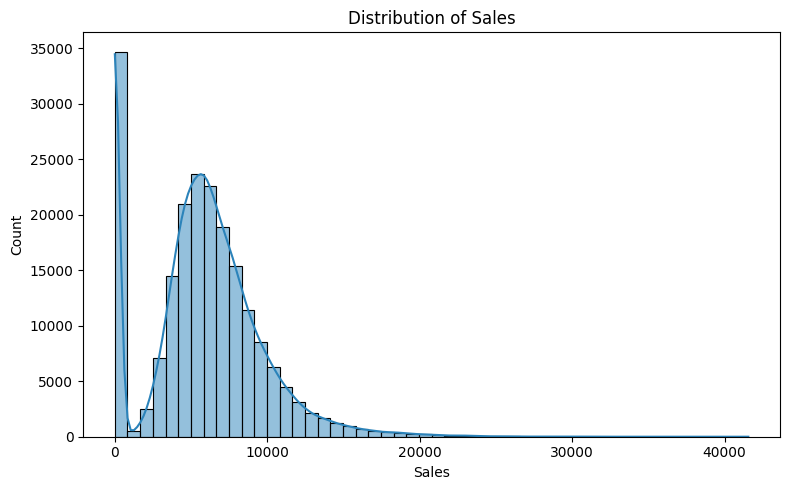

Stores were open in 83.0% of all records.
Share of high-sales days (>20,000): 0.40%

Duplicate rows before: 0
Duplicate rows after:  0

No missing values remaining.
Time-based features created: ['Year', 'Month', 'Day', 'DayOfWeek', 'IsWeekend']


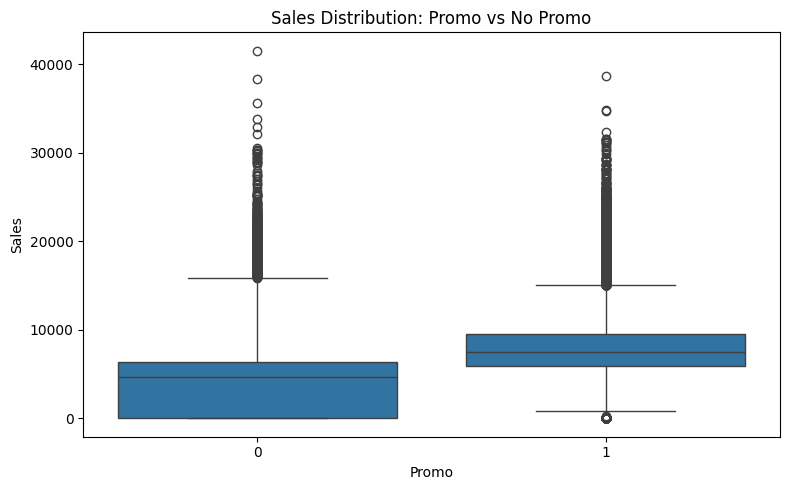


Share of extreme sales values (>20000): 0.40%

Categorical columns to encode: ['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval']
Data shape after encoding: (168798, 18)
Initial correlation matrix (snippet):


,Store,DayOfWeek,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,IsWeekend
Store,1.00,0.00,-0.00,0.01,0.00,-0.02,0.01,-0.03,-0.03,-0.01,0.01,0.01,0.01,-0.01,0.00,-0.00,-0.00,0.00
DayOfWeek,0.00,1.00,-0.29,-0.00,-0.14,-0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.01,-0.02,0.01,0.67
Promo,-0.00,-0.29,1.00,-0.01,0.03,0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00,0.02,-0.01,-0.12,-0.41
StateHoliday,0.01,-0.00,-0.01,1.00,0.02,-0.00,-0.00,0.01,-0.00,-0.00,-0.01,-0.01,-0.01,0.01,-0.00,0.00,-0.00,-0.01
SchoolHoliday,0.00,-0.14,0.03,0.02,1.00,-0.00,-0.01,-0.00,0.00,0.00,-0.01,-0.01,-0.01,0.01,-0.04,0.12,0.04,-0.20


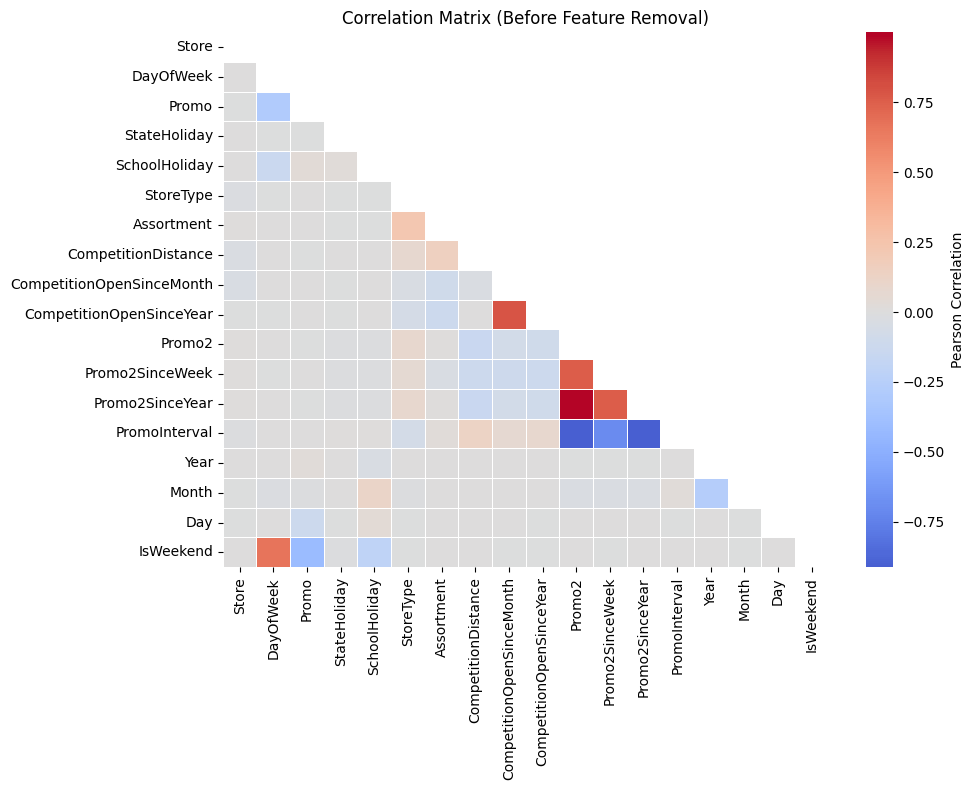


Detected highly correlated features (correlation > 0.9):
['Promo2SinceYear', 'PromoInterval']

Correlation matrix after feature removal (snippet):


,Store,DayOfWeek,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Year,Month,Day,IsWeekend
Store,1.00,0.00,-0.00,0.01,0.00,-0.02,0.01,-0.03,-0.03,-0.01,0.01,0.01,0.00,-0.00,-0.00,0.00
DayOfWeek,0.00,1.00,-0.29,-0.00,-0.14,-0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.01,-0.02,0.01,0.67
Promo,-0.00,-0.29,1.00,-0.01,0.03,0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.02,-0.01,-0.12,-0.41
StateHoliday,0.01,-0.00,-0.01,1.00,0.02,-0.00,-0.00,0.01,-0.00,-0.00,-0.01,-0.01,-0.00,0.00,-0.00,-0.01
SchoolHoliday,0.00,-0.14,0.03,0.02,1.00,-0.00,-0.01,-0.00,0.00,0.00,-0.01,-0.01,-0.04,0.12,0.04,-0.20



Number of numerical features before cleaning: 18
Number of numerical features after cleaning:  16

Train/Test shapes: (135038, 16), (33760, 16)
X scaled with StandardScaler, y scaled with StandardScaler for training.

Training XGBoost (default parameters)...
XGBoost — MAE: 0.267, RMSE: 0.381, R²: 0.858, WAPE: 0.118, MAPE: 13.419%


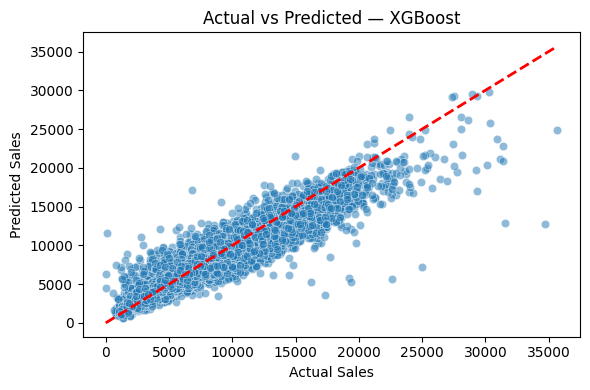


Training CatBoost (default parameters)...
CatBoost — MAE: 0.273, RMSE: 0.389, R²: 0.852, WAPE: 0.121, MAPE: 13.727%


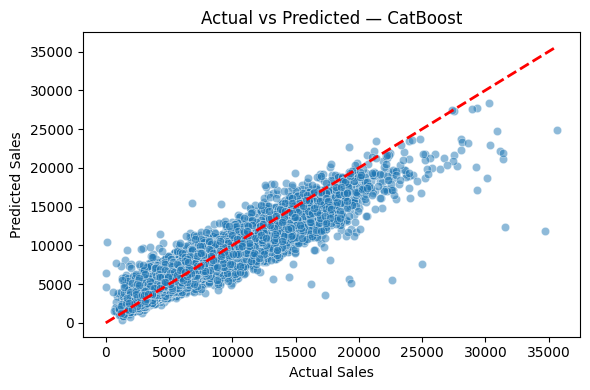


Training RandomForest (default parameters)...
RandomForest — MAE: 0.234, RMSE: 0.372, R²: 0.865, WAPE: 0.104, MAPE: 11.058%


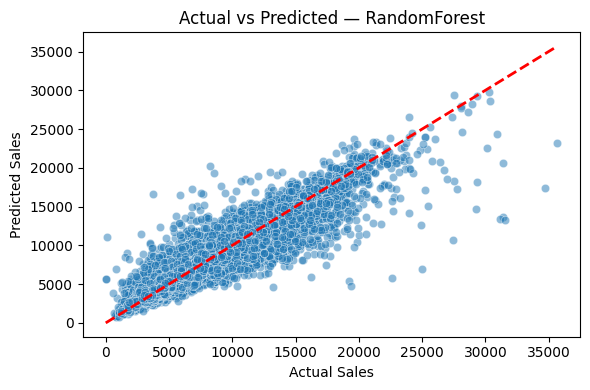


Running Grid Search for RandomForest...


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
[I 2025-11-27 19:07:20,147] A new study created in memory with name: no-name-97e3a6d7-ceac-4ab3-8168-df5d959e96b3


Best RandomForest parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 400}

Running Bayesian Optimization for CatBoost (GPU)...


[I 2025-11-27 19:07:21,728] Trial 0 finished with value: 1177.9285922020154 and parameters: {'depth': 8, 'learning_rate': 0.11914822706693268, 'iterations': 408, 'l2_leaf_reg': 8.77812496522107}. Best is trial 0 with value: 1177.9285922020154.
[I 2025-11-27 19:07:26,339] Trial 1 finished with value: 973.2068583993793 and parameters: {'depth': 10, 'learning_rate': 0.1425069810650644, 'iterations': 444, 'l2_leaf_reg': 8.945277063265921}. Best is trial 1 with value: 973.2068583993793.
[I 2025-11-27 19:07:30,205] Trial 2 finished with value: 1097.0463330924078 and parameters: {'depth': 9, 'learning_rate': 0.11107726697331542, 'iterations': 400, 'l2_leaf_reg': 8.120130004701096}. Best is trial 1 with value: 973.2068583993793.
[I 2025-11-27 19:07:34,013] Trial 3 finished with value: 1066.1310700460685 and parameters: {'depth': 8, 'learning_rate': 0.14707739895401642, 'iterations': 482, 'l2_leaf_reg': 8.563382709600914}. Best is trial 1 with value: 973.2068583993793.
[I 2025-11-27 19:07:38,51

Best CatBoost parameters: {'depth': 10, 'learning_rate': 0.14319331302423796, 'iterations': 499, 'l2_leaf_reg': 8.864990115279172}

CatBoost Performance Metrics (tuned):
MAE:   0.2097
RMSE:  0.3093
R²:    0.9065
WAPE:  0.0931
MAPE:  10.3902%

RandomForest Performance Metrics (tuned):
MAE:   0.2330
RMSE:  0.3697
R²:    0.8664
WAPE:  0.1034
MAPE:  10.9874%

Building ensemble models...
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 658
[LightGBM] [Info] Number of data points in the train set: 135038, number of used features: 16
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: NVIDIA A100-SXM4-80GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 13 dense feature groups (2.06 MB) transferred to GPU in 0.003082 secs. 1 sparse feature groups
[LightGBM] [Info] Start trai

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Ensembles built successfully.
Saved: data/model_results.csv

Actual vs Predicted — RandomForest (Tuned)


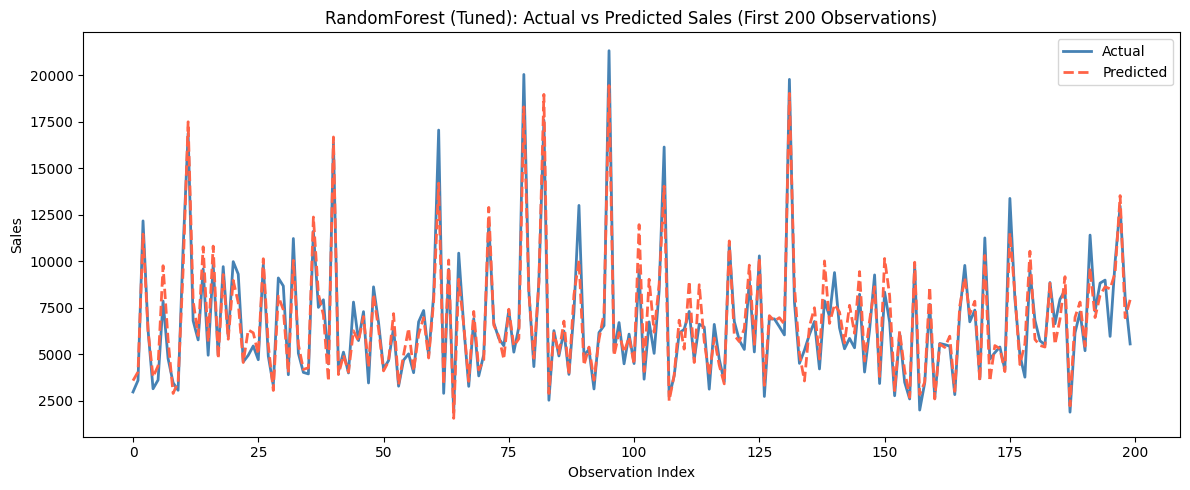

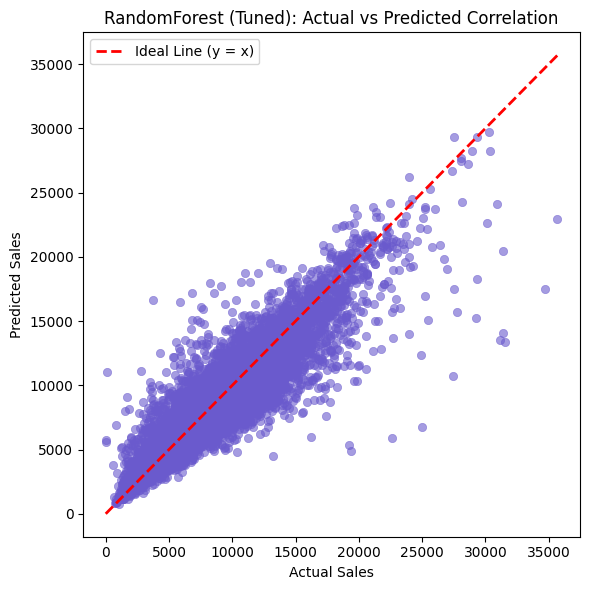

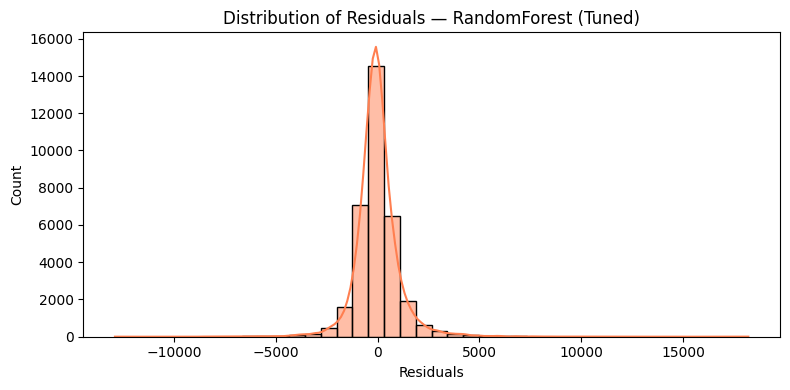

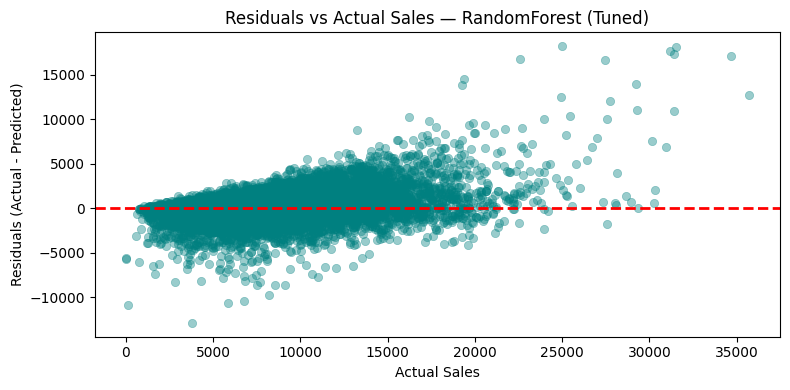


Actual vs Predicted — CatBoost (Tuned)


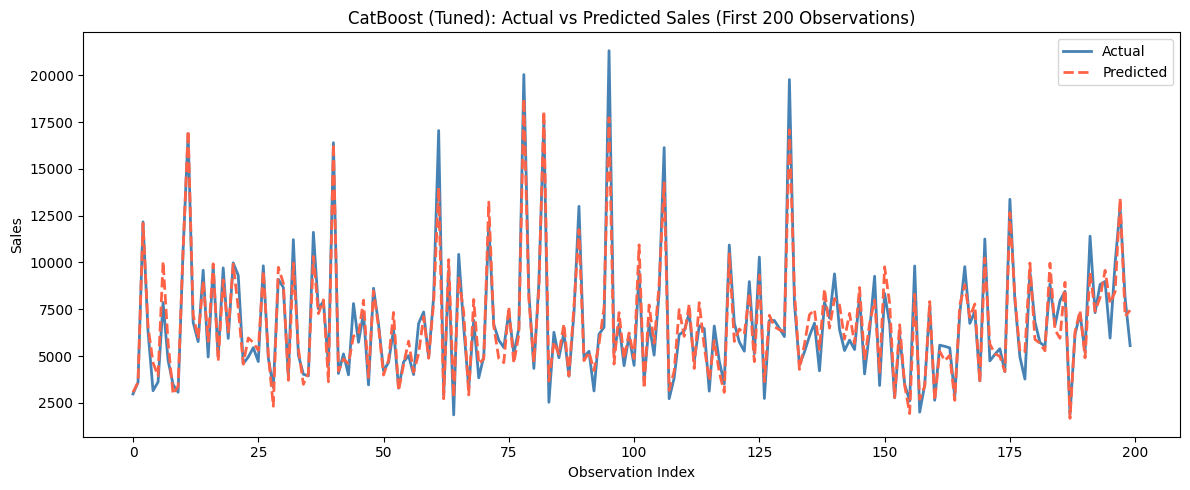

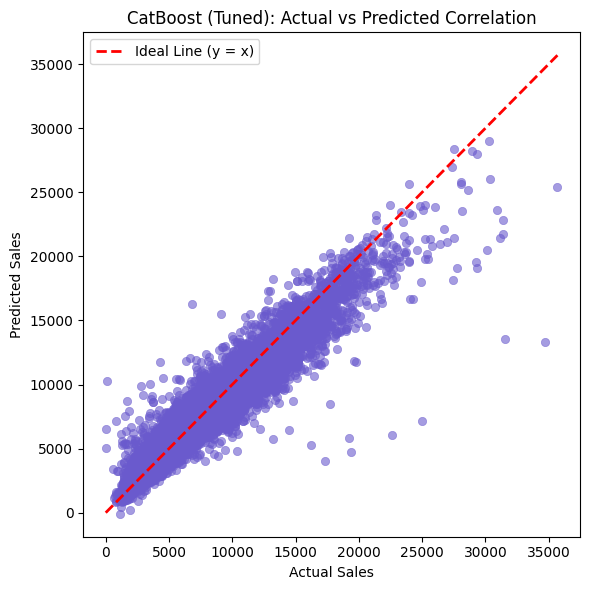

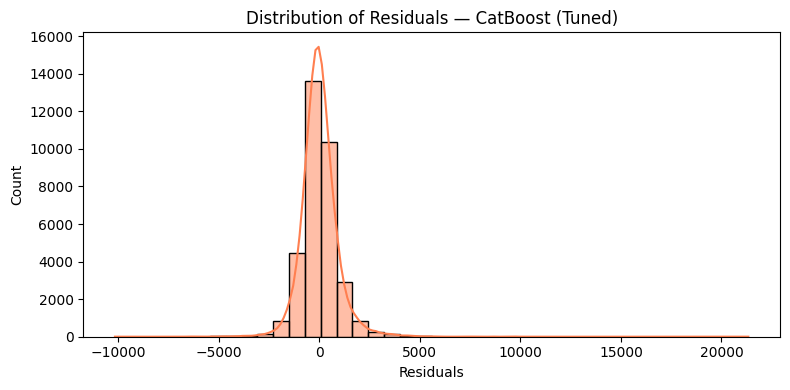

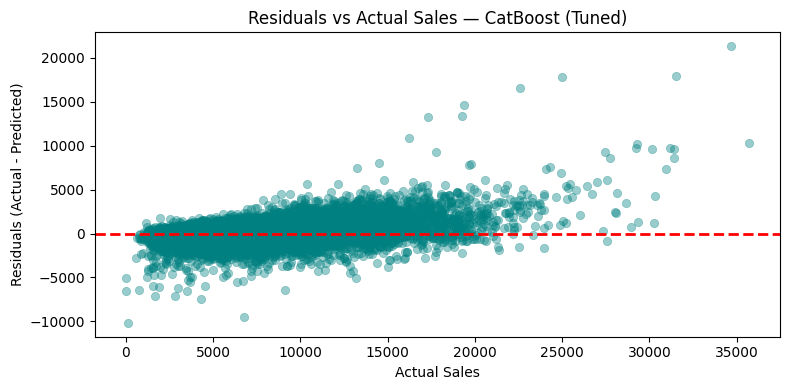


Actual vs Predicted — Weighted Ensemble


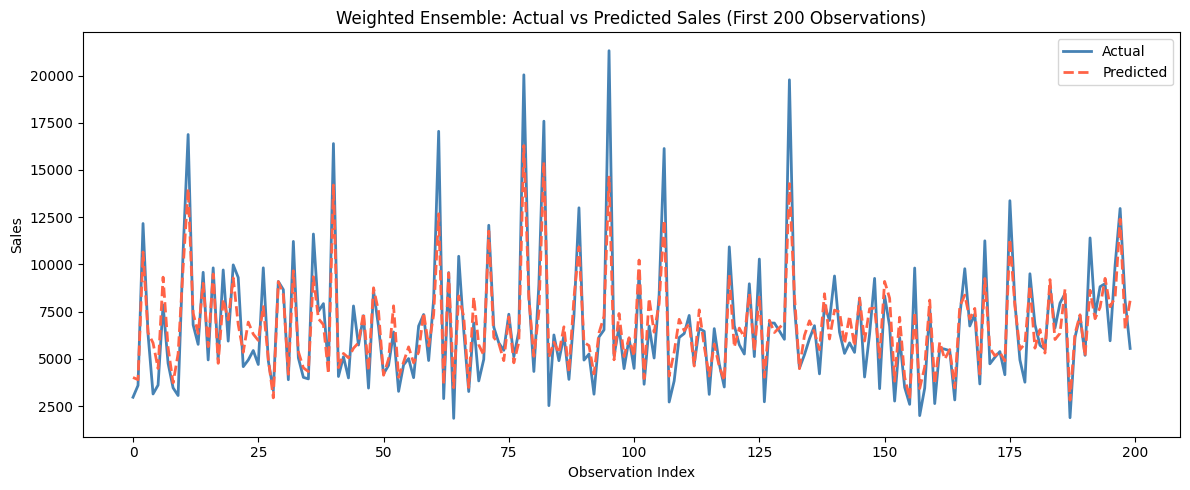

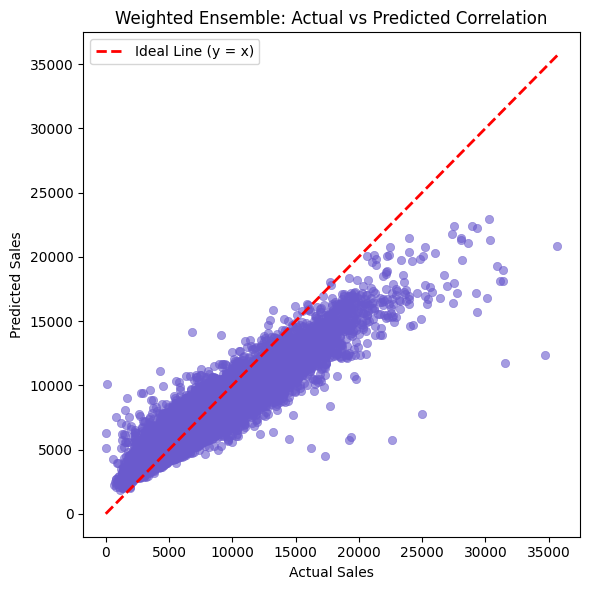

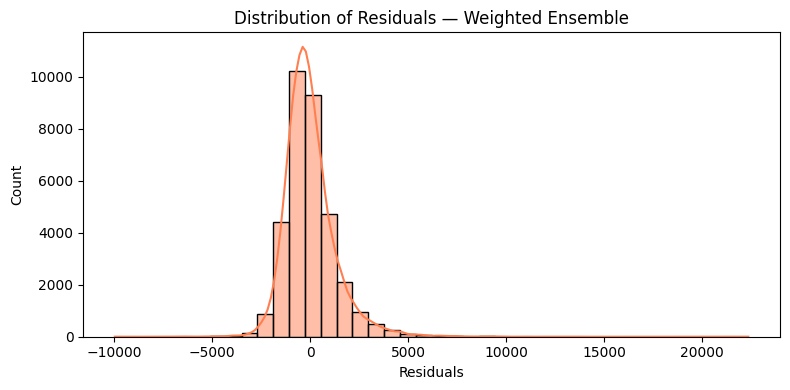

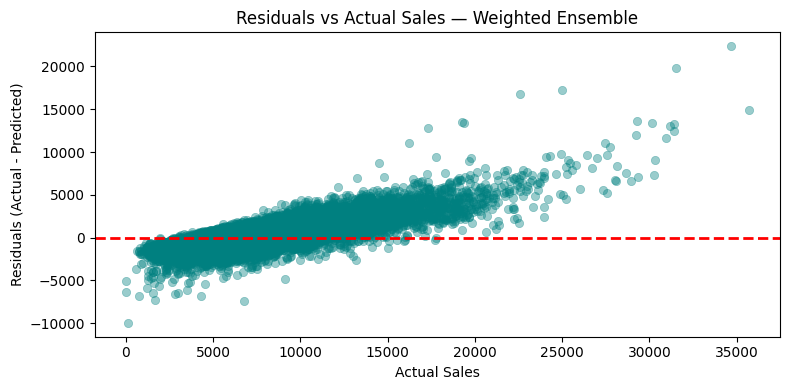


Actual vs Predicted — Stacked Ensemble


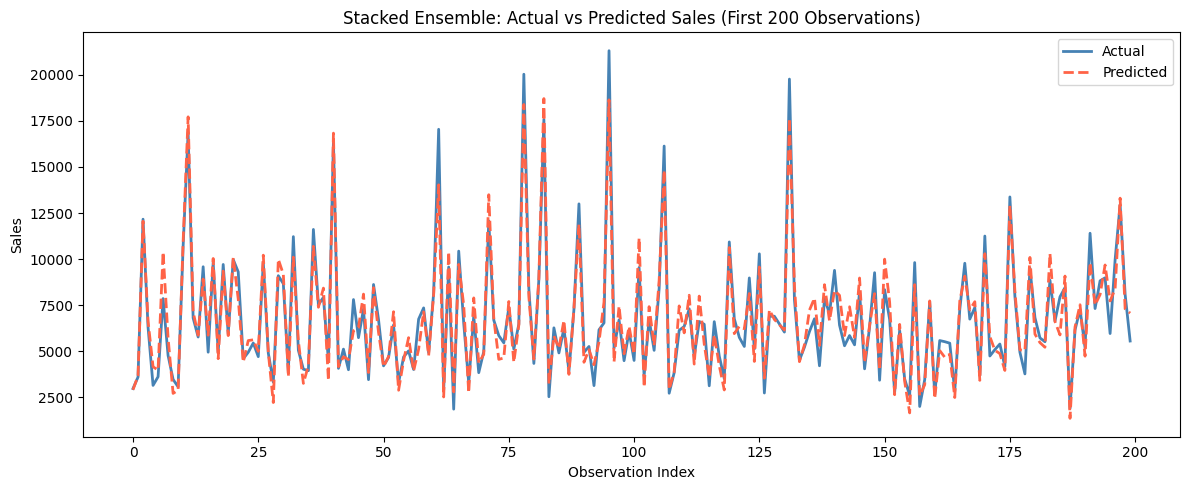

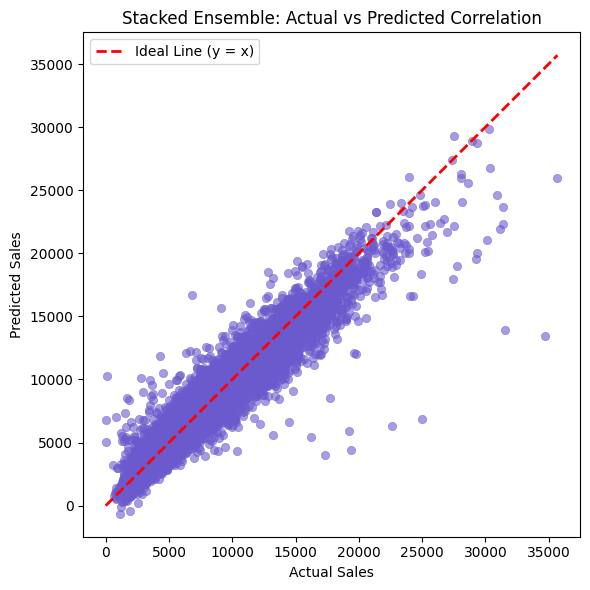

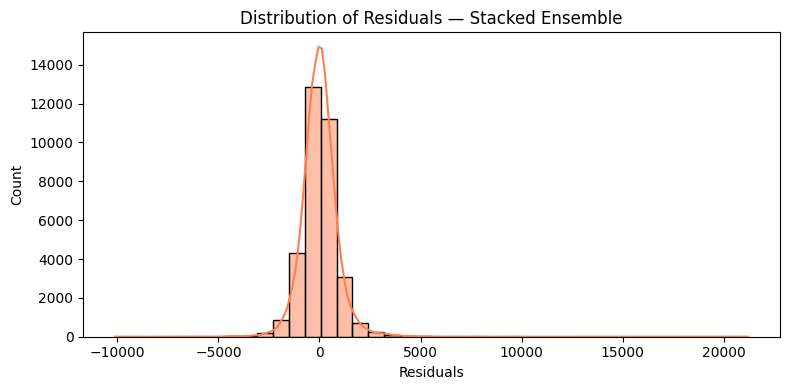

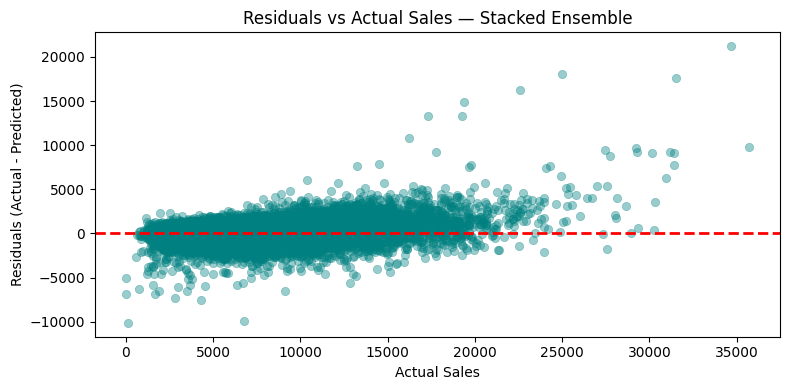


Outlier analysis — CatBoost (Tuned)

CatBoost (Tuned): Found 11 outliers (0.03% of all data points)


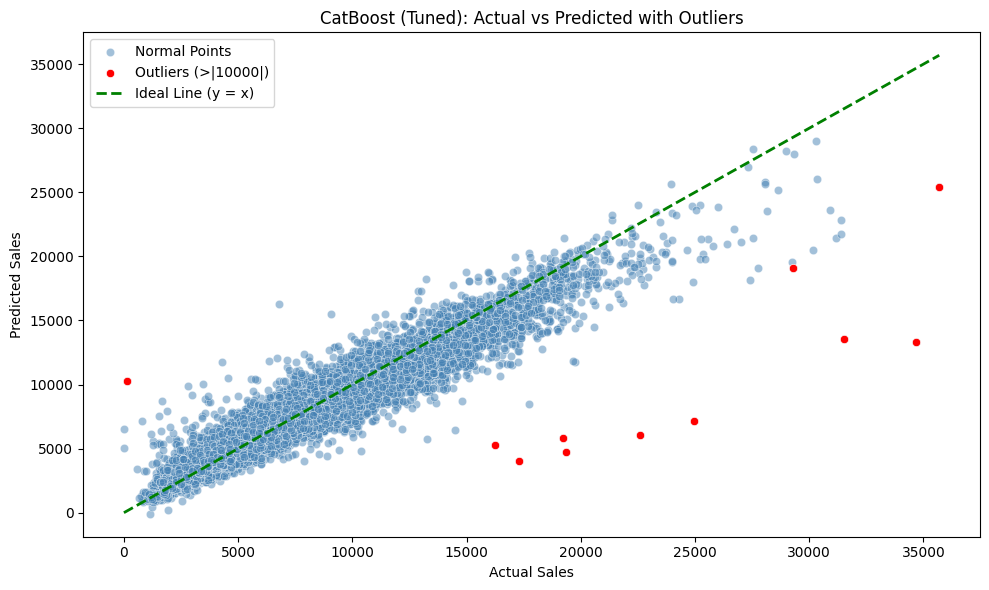


Outlier analysis — RandomForest (Tuned)

RandomForest (Tuned): Found 22 outliers (0.07% of all data points)


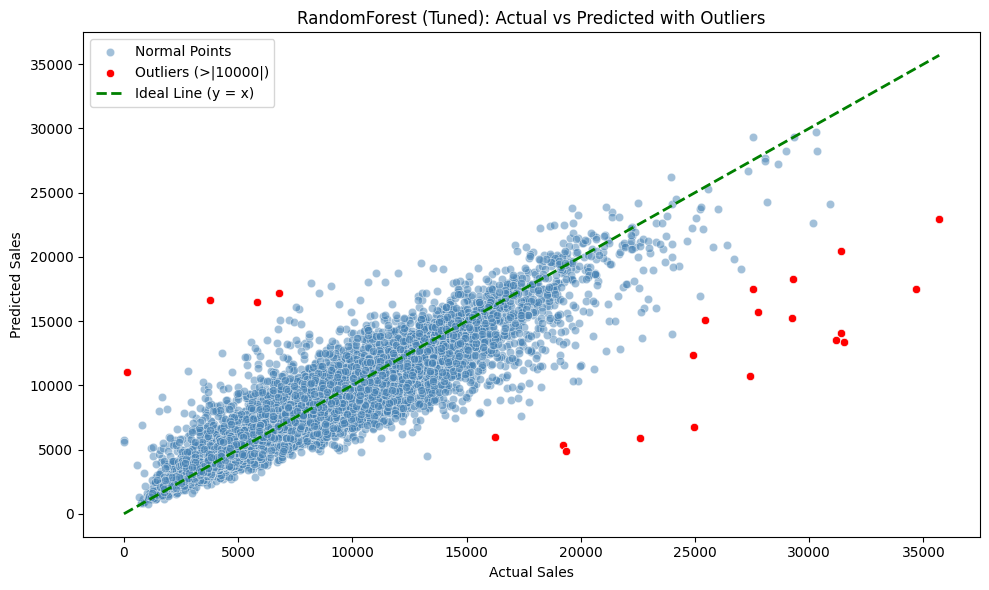


Outlier analysis — Weighted Ensemble

Weighted Ensemble: Found 18 outliers (0.05% of all data points)


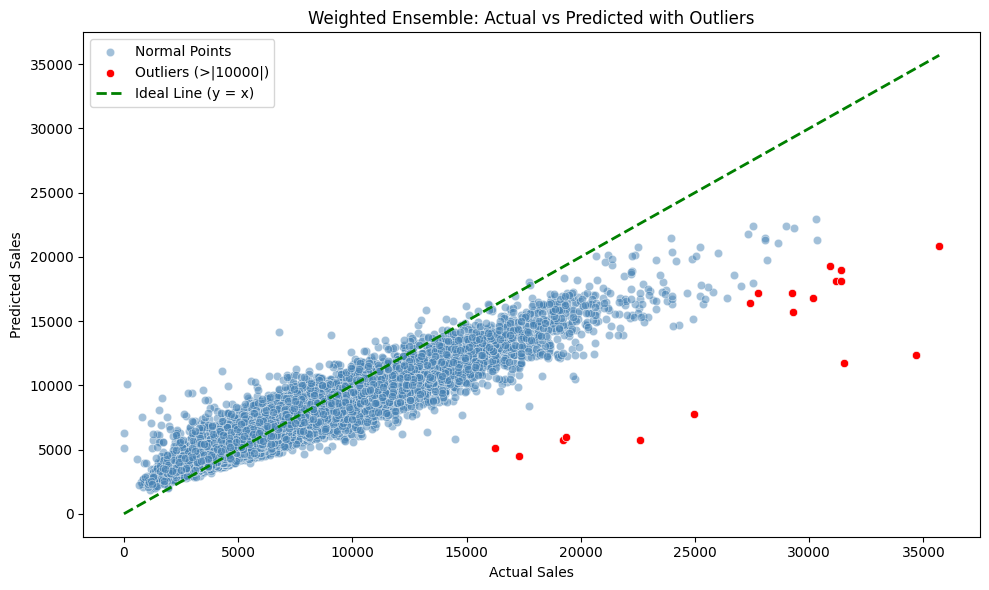


Outlier analysis — Stacked Ensemble

Stacked Ensemble: Found 9 outliers (0.03% of all data points)


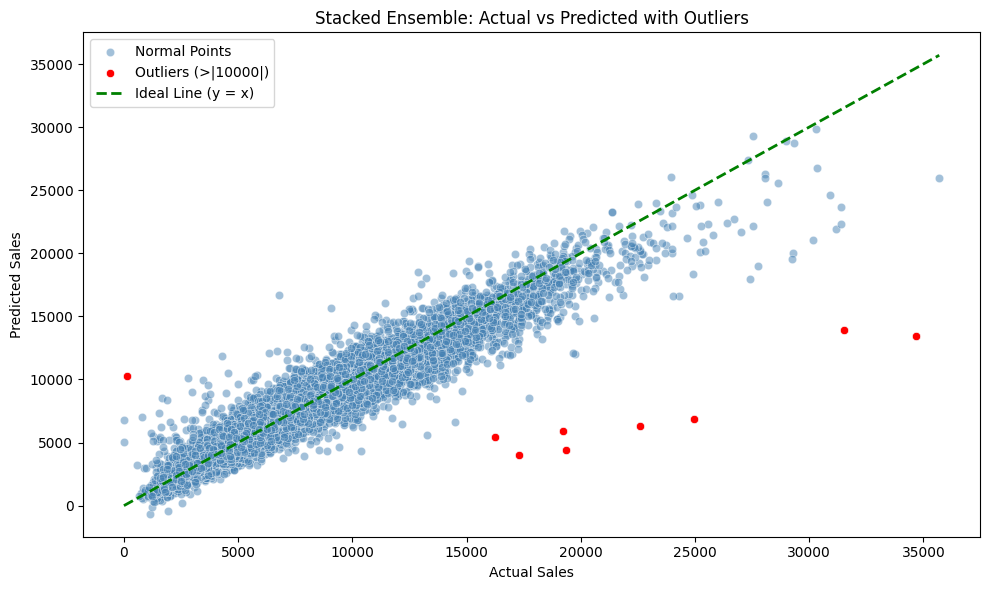


Residual heatmaps...


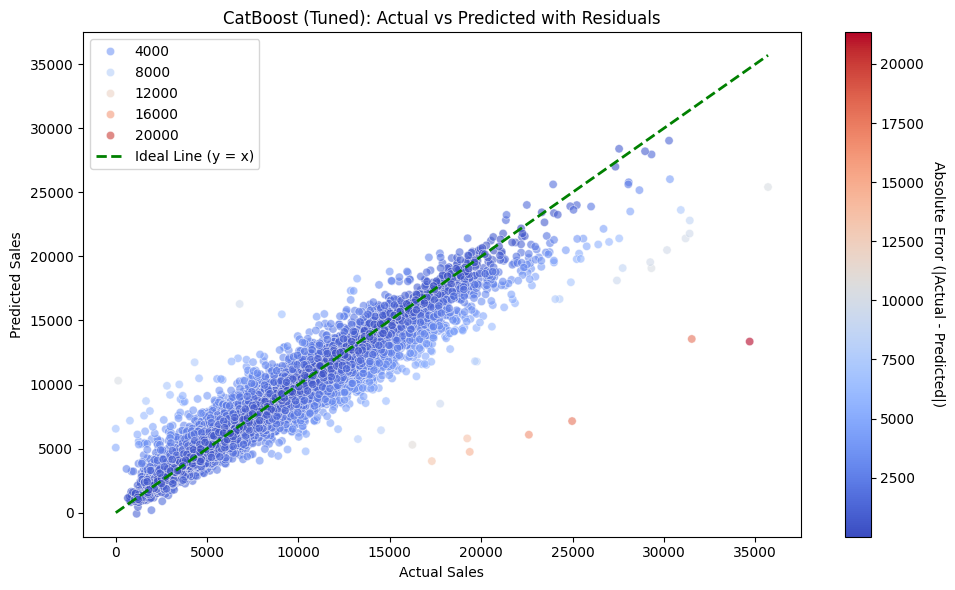

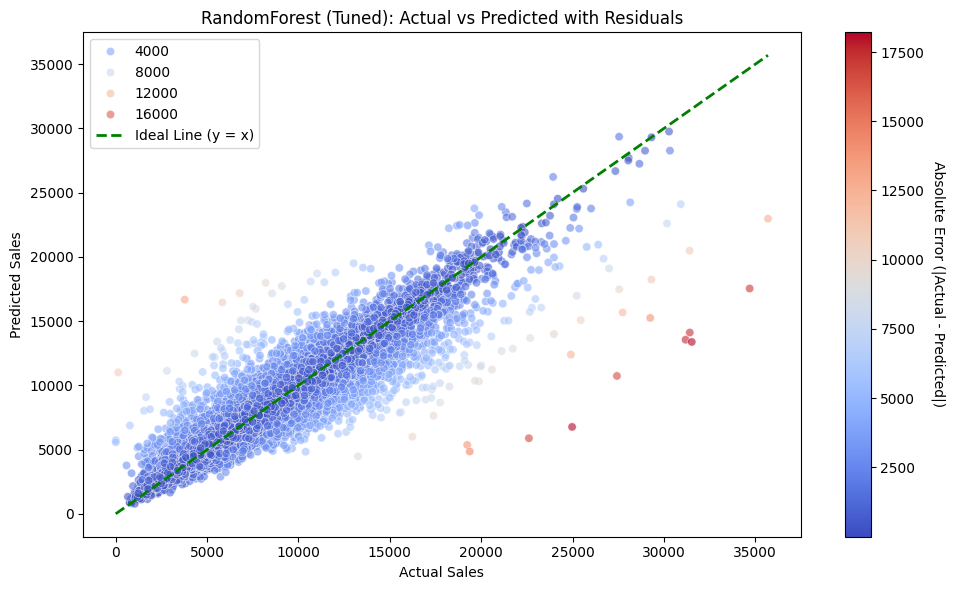

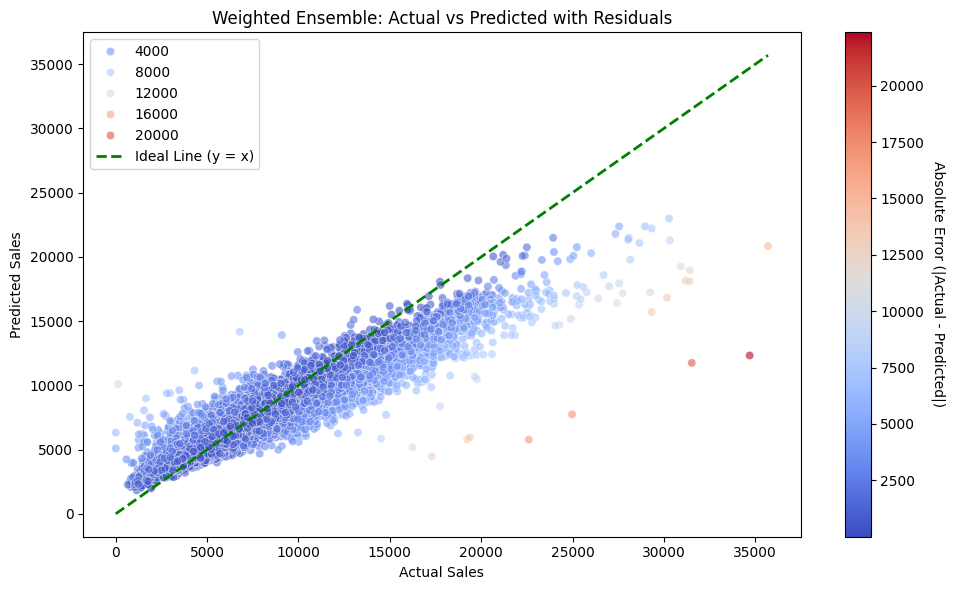

[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 658
[LightGBM] [Info] Number of data points in the train set: 135038, number of used features: 16
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: NVIDIA A100-SXM4-80GB, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 13 dense feature groups (2.06 MB) transferred to GPU in 0.003186 secs. 1 sparse feature groups
[LightGBM] [Info] Start training from score 0.000000
Running fast SHAP on 300 samples and 16 features...

Analyzing model: CatBoost


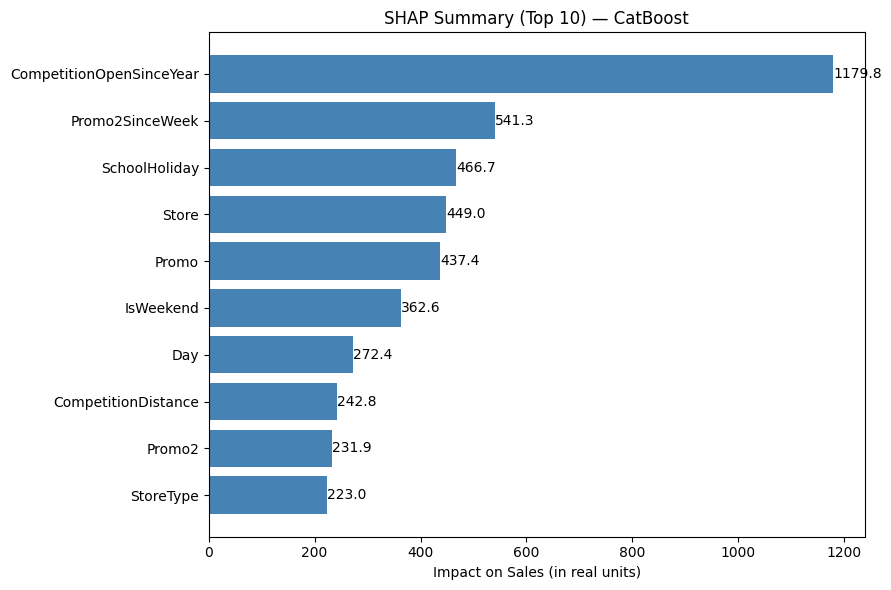

Analyzing model: RandomForest


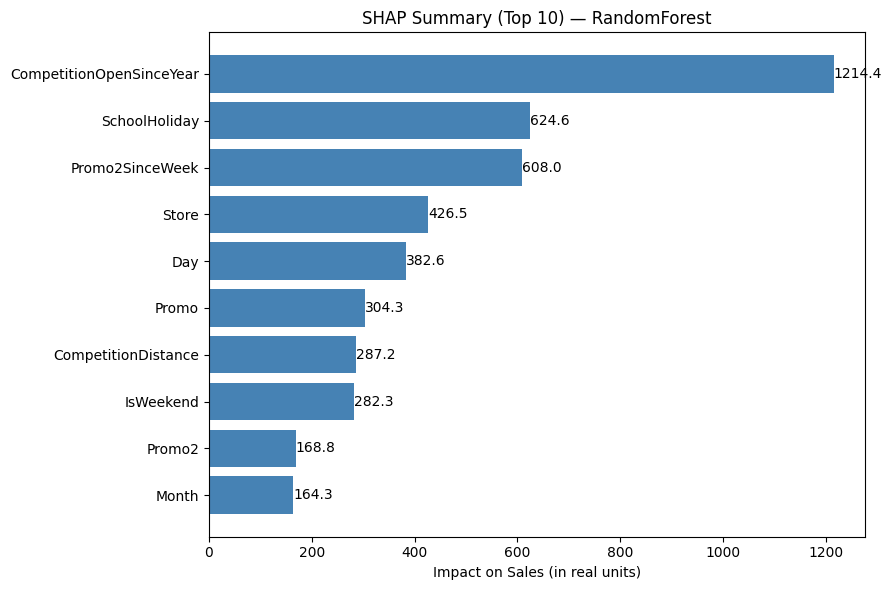

Analyzing model: LightGBM


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


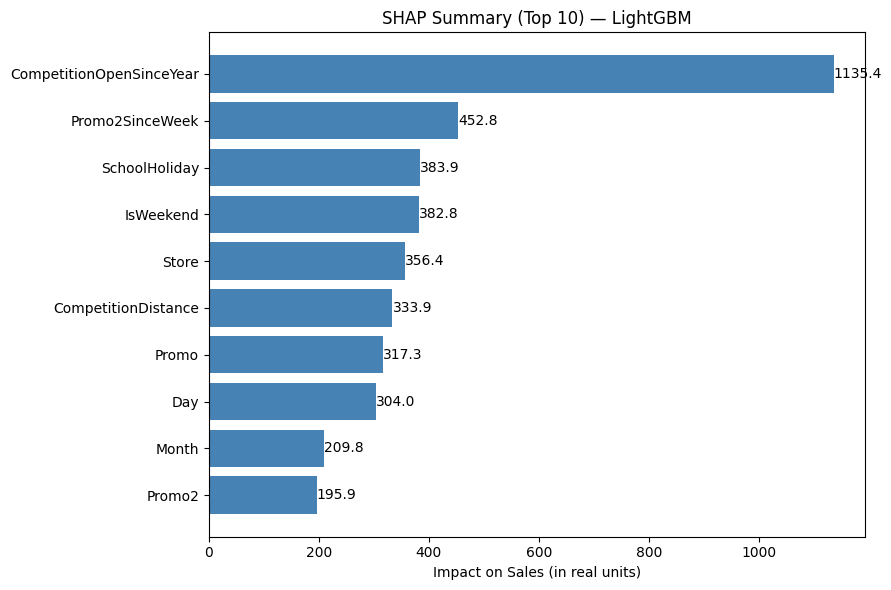

Analyzing model: XGBoost


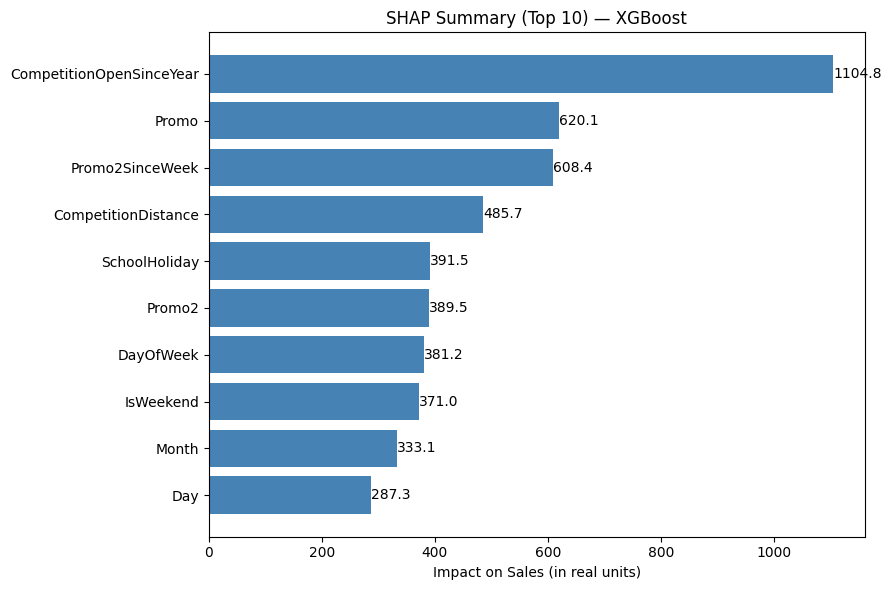

Analyzing model: ElasticNet


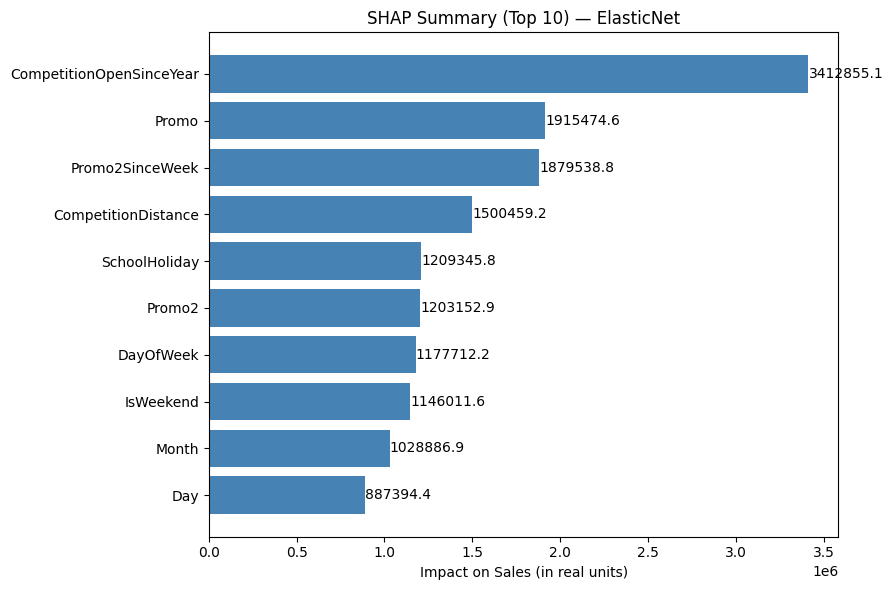


Fast SHAP analysis completed.

Final Model Performance Summary:
| Model                                  |    MAE |   RMSE |   WAPE |    MAPE |     R2 | Time (s)   |
|----------------------------------------|--------|--------|--------|---------|--------|------------|
| XGBoost (Base)                         | 0.2667 | 0.3805 | 0.1184 | 13.4193 | 0.8585 | 0.49 s     |
| CatBoost (Base)                        | 0.2734 | 0.3892 | 0.1214 | 13.727  | 0.852  | 5.49 s     |
| RandomForest (Base)                    | 0.2344 | 0.3715 | 0.104  | 11.0583 | 0.8651 | 78.02 s    |
| CatBoost (Tuned)                       | 0.2097 | 0.3093 | 0.0931 | 10.3902 | 0.9065 | 0.02 s     |
| RandomForest (Tuned)                   | 0.233  | 0.3697 | 0.1034 | 10.9874 | 0.8664 | 6.82 s     |
| Weighted Ensemble (GPU)                | 0.3052 | 0.4317 | 0.1354 | 15.7027 | 0.8179 | 9.45 s     |
| Stacked Ensemble (GPU base + CPU meta) | 0.207  | 0.3013 | 0.0919 | 10.2976 | 0.9113 | 10.13 s    |


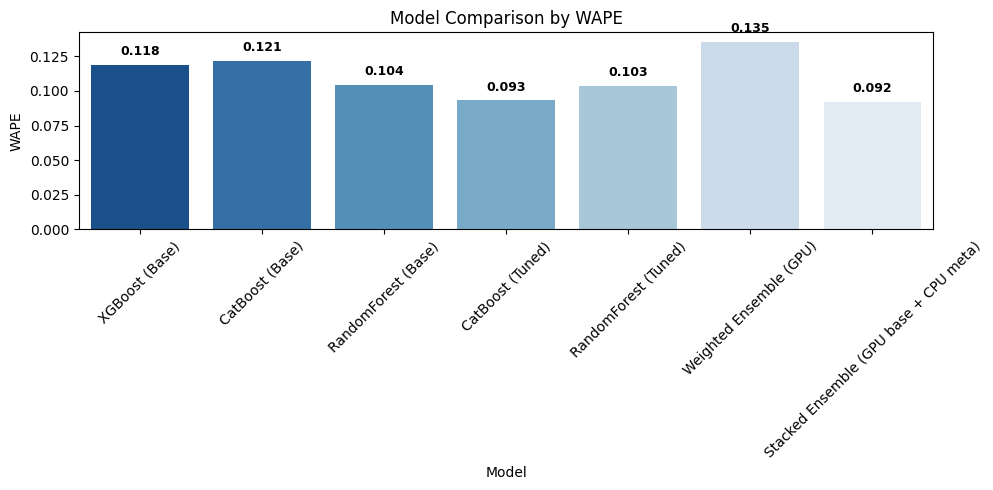

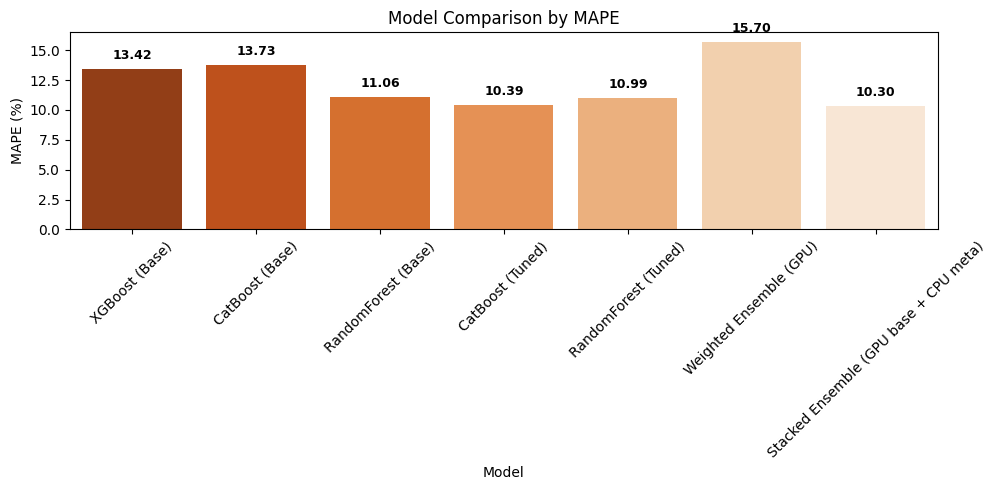

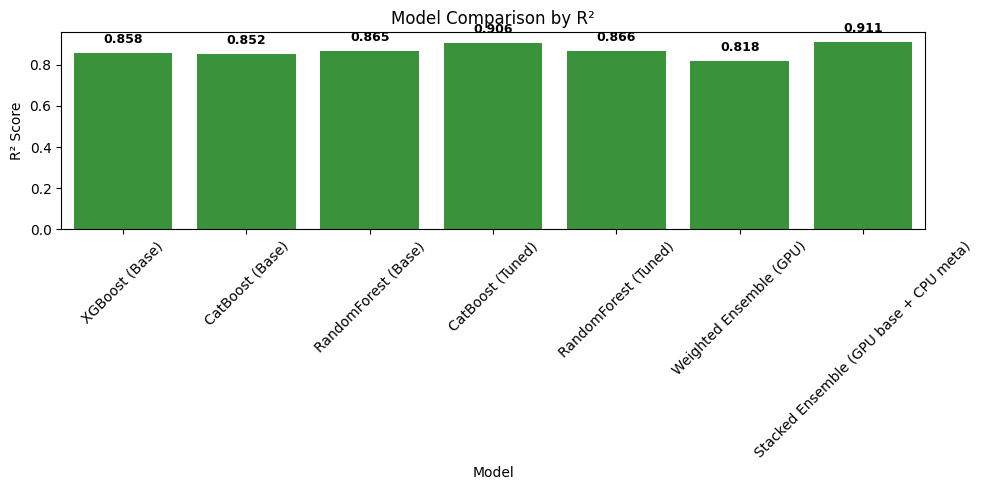


Best model by WAPE: Stacked Ensemble (GPU base + CPU meta)
Best model by MAPE: Stacked Ensemble (GPU base + CPU meta)
Best model by R²:   Stacked Ensemble (GPU base + CPU meta)
Saved: data/metrics.csv

Best RandomForest parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 400}
Best CatBoost parameters: {'depth': 10, 'learning_rate': 0.14319331302423796, 'iterations': 499, 'l2_leaf_reg': 8.864990115279172}

Pipeline completed.


In [6]:
if __name__ == "__main__":
    main()